Step 0: Install and import dependencies


In [ ]:
!pip install -q kagglehub tensorflow matplotlib seaborn

Import

In [ ]:
import os
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import json
from google.colab import files

Step 1: Setup

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

Step 2: Download dataset from KaggleHub


In [ ]:
dataset_path = kagglehub.dataset_download("anthonytherrien/image-classification-64-classes-animal")
DATA_DIR = os.path.join(os.path.expanduser("~"), ".cache/kagglehub/datasets/anthonytherrien/image-classification-64-classes-animal", "1.complete", "animal_dataset_64_classes")

100%|██████████| 5.71G/5.71G [00:54<00:00, 112MB/s]

Extracting files...


Step 3: Data generators with augmentation

In [ ]:
import os
import kagglehub
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = kagglehub.dataset_download("anthonytherrien/image-classification-64-classes-animal")
DATA_DIR = os.path.join(dataset_path, "image")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    brightness_range=(0.8, 1.2),
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

class_labels = list(train_generator.class_indices.keys())

Found 11515 images belonging to 64 classes.
Found 2862 images belonging to 64 classes.


Step 4: Build model with MobileNetV2

In [ ]:
base_model = MobileNetV2(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')
base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(64, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=5)]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,602,368 (9.93 MB)

 Trainable params: 344,384 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Step 5: Early stopping callback


In [ ]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)


Step 6: Train the model


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,  # Let EarlyStopping decide when to stop
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 398s 1s/step - accuracy: 0.7535 - loss: 1.1245 - top_k_categorical_accuracy: 0.8565 - val_accuracy: 0.9710 - val_loss: 0.0732 - val_top_k_categorical_accuracy: 0.9997
Epoch 2/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 351s 975ms/step - accuracy: 0.9774 - loss: 0.0795 - top_k_categorical_accuracy: 0.9992 - val_accuracy: 0.9787 - val_loss: 0.0603 - val_top_k_categorical_accuracy: 0.9997
Epoch 3/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 337s 937ms/step - accuracy: 0.9811 - loss: 0.0601 - top_k_categorical_accuracy: 0.9996 - val_accuracy: 0.9878 - val_loss: 0.0372 - val_top_k_categorical_accuracy: 0.9997
Epoch 4/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 340s 944ms/step - accuracy: 0.9885 - loss: 0.0392 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.9818 - val_loss: 0.0513 - val_top_k_categorical_accuracy: 0.9993
Epoch 5/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 332s 924ms/step - accuracy: 0.9861 - loss: 0.0413 - top_k_categorical_accuracy: 0.9998 - val_accuracy: 0.9843 - val_loss: 0

Step 7: Plot training history

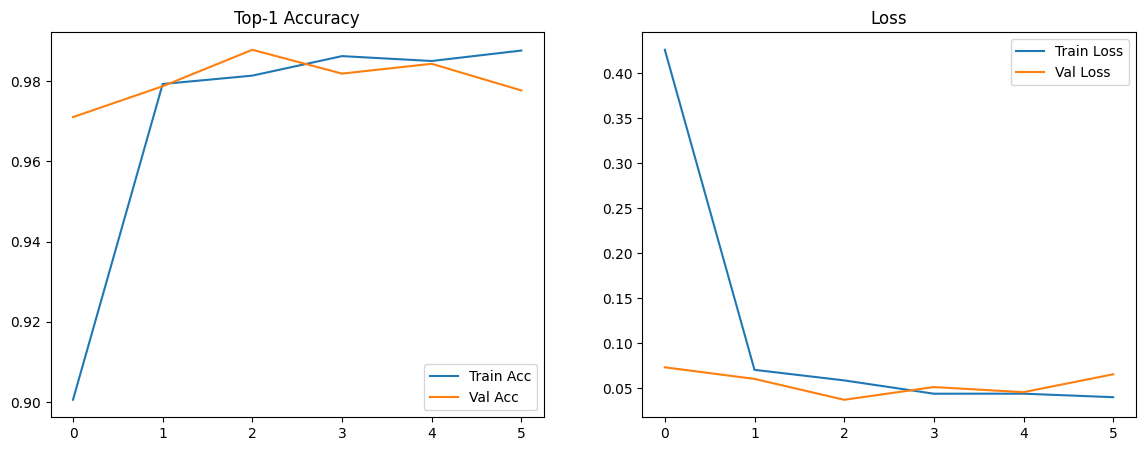

In [ ]:
def plot_history(hist):
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(hist.history['accuracy'], label='Train Acc')
    plt.plot(hist.history['val_accuracy'], label='Val Acc')
    plt.title('Top-1 Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist.history['loss'], label='Train Loss')
    plt.plot(hist.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.legend()
    plt.show()

plot_history(history)

Step 8: Evaluation

90/90 ━━━━━━━━━━━━━━━━━━━━ 74s 747ms/step
              precision    recall  f1-score   support

    antelope       0.00      0.00      0.00        43
        bear       0.05      0.05      0.05        43
      beaver       0.03      0.02      0.02        43
         bee       0.02      0.02      0.02        43
       bison       0.00      0.00      0.00        43
   blackbird       0.00      0.00      0.00        43
     buffalo       0.00      0.00      0.00        43
   butterfly       0.00      0.00      0.00        43
       camel       0.00      0.00      0.00        43
         cat       0.02      0.02      0.02        86
     cheetah       0.00      0.00      0.00        43
  chimpanzee       0.00      0.00      0.00        43
  chinchilla       0.00      0.00      0.00        43
         cow       0.02      0.02      0.02        43
        crab       0.00      0.00      0.00        43
   crocodile       0.00      0.00      0.00        43
        deer       0.00      0.00      

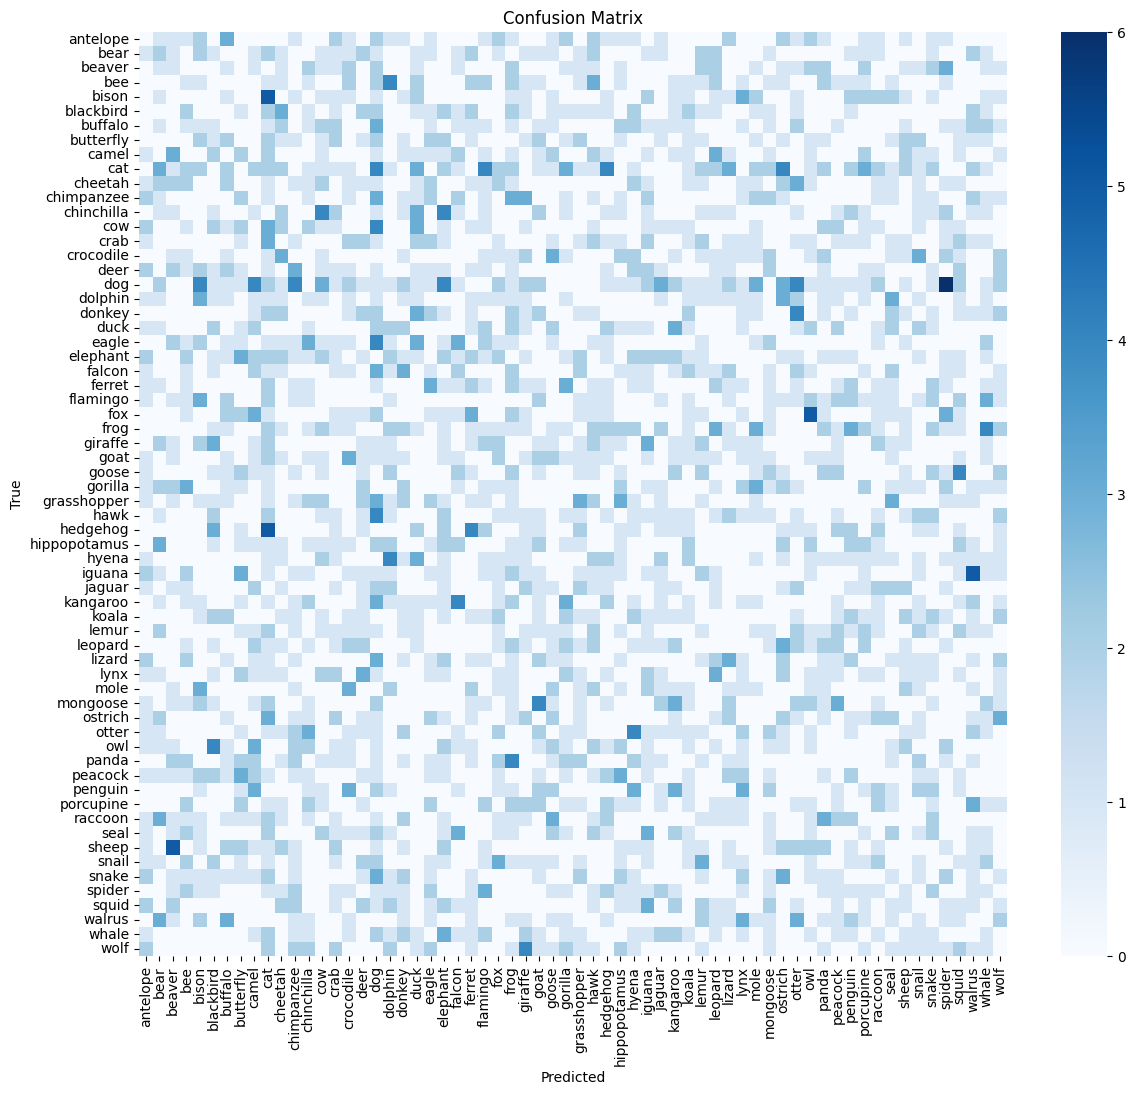

In [ ]:
val_generator.reset()
preds = model.predict(val_generator)
y_pred = np.argmax(preds, axis=1)
y_true = val_generator.classes

print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="Blues", xticklabels=class_labels, yticklabels=class_labels, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


Step 9: Upload a test image and predict

In [ ]:
uploaded = files.upload()
from tensorflow.keras.preprocessing import image

for fn in uploaded.keys():
    img_path = fn
    img = image.load_img(img_path, target_size=IMG_SIZE)
    plt.imshow(img)
    plt.axis('off')
    plt.title("Uploaded Test Image")
    plt.show()

    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, 0)

    pred = model.predict(img_array)[0]
    top5 = np.argsort(pred)[-5:][::-1]

    print("\nTop 5 Predictions:")
    for i in top5:
        print(f"{class_labels[i]}: {pred[i]*100:.2f}%")

Step 10: Save model and labels

In [ ]:
#Save model in HDF5 format
model.save("animal_model.h5")

#Save class labels
with open("labels.json", "w") as f:
    json.dump(train_generator.class_indices, f)

#Download model and labels
files.download("animal_model.h5")
files.download("labels.json")
